# Finetuning de Stable Diffusion con ilustraciones de libros antiguos

**Entrega final del Módulo Modelos de Generación de Imagen**

En esta entrega hacemos un *finetuning* completo del modelo
[`CompVis/stable-diffusion-v1-4`](https://huggingface.co/CompVis/stable-diffusion-v1-4)
(el mismo visto en clase) pero usando un dataset distinto: un conjunto de
**ilustraciones de libros antiguos**
[`gigant/oldbookillustrations`](https://huggingface.co/datasets/gigant/oldbookillustrations).

El código está basado en el notebook visto en clase (finetuning con Pokemon), con las
adaptaciones necesarias para este nuevo dataset:

- Del dataset solo usamos la columna **`1600px`** (la imagen) y la columna **`info_alt`**
  (la descripción de la imagen).
- Las imágenes **no son cuadradas** (la altura varía), por lo que adaptamos las
  transformaciones de *crop* y *resize* para obtener imágenes cuadradas de 512x512.

Pasos del notebook:
1. Comportamiento original del modelo pre-entrenado (imagen **antes** del finetuning).
2. Carga y preparación del dataset.
3. Carga de las componentes del modelo por separado.
4. Preparación del entrenamiento.
5. Entrenamiento (finetuning de la UNet).
6. Subida del modelo finetuneado a Hugging Face.
7. Carga del modelo finetuneado y generación (imagen **después** del finetuning).
8. Comparación antes vs. después.


# 0. Instalación de librerías

In [16]:
# Instalamos las dependencias desde el fichero requirements.txt:
%pip install -qq -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [17]:
# Importamos las librerias necesarias:
from diffusers import StableDiffusionPipeline, DDPMScheduler
from diffusers import UNet2DConditionModel, AutoencoderKL, LMSDiscreteScheduler
from transformers import CLIPTextModel, CLIPTokenizer
from datasets import load_dataset
from accelerate import Accelerator
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageFile
import os
from tqdm import tqdm

# Algunas ilustraciones del dataset estan truncadas (mal terminadas). Permitimos que PIL
# las cargue igualmente en lugar de lanzar un error "image file is truncated":
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [18]:
# Usamos la GPU para el entrenamiento y la generacion de imagenes:
assert torch.cuda.is_available(), "No se ha detectado GPU disponible."
device = "cuda"
print(f"Usando dispositivo: {device} ({torch.cuda.get_device_name(0)})")

Usando dispositivo: cuda (NVIDIA GeForce RTX 5090)


### Autenticación en Hugging Face

Hacemos login en Hugging Face al inicio usando el token del fichero `.env` (variable
`HF_API_KEY`). Autenticarse antes de descargar el modelo y el dataset da mejores cuotas de
descarga, y reutilizamos el mismo token al final para subir el modelo finetuneado.

> El token (con permisos de **escritura**) se crea en https://huggingface.co/settings/tokens
> y se guarda en `.env` como `HF_API_KEY=...`.

In [19]:
from dotenv import load_dotenv
from huggingface_hub import login

# Cargamos el token de Hugging Face desde el fichero .env (variable HF_API_KEY) y hacemos
# login al principio. Asi quedamos autenticados para TODO el notebook: tanto las DESCARGAS
# (modelo y dataset, con mejores cuotas) como la posterior SUBIDA del modelo finetuneado.
load_dotenv()
hf_token = os.getenv("HF_API_KEY")
assert hf_token, "No se ha encontrado HF_API_KEY en el fichero .env"

login(token=hf_token)
print("Login en Hugging Face correcto.")

Login en Hugging Face correcto.


# Panel de configuración

Todos los ajustes del notebook centralizados en un único sitio. Modifica aquí los valores (modelo base, dataset, hiperparámetros, rutas de salida) sin tener que buscarlos por el resto de celdas.

In [ ]:
# =========================================================================
# PANEL DE CONFIGURACIÓN
# Todos los ajustes del notebook centralizados aquí.
# =========================================================================

# --- Modelo base ---
pretrained_model_name = "CompVis/stable-diffusion-v1-4"

# --- Dataset ---
dataset_name = "gigant/oldbookillustrations"
image_column = "1600px"            # columna con la imagen
caption_column = "info_alt"        # columna con la descripcion
max_train_samples = 200            # None para usar TODAS las muestras casi cuadradas

# Tolerancia para considerar una imagen "casi cuadrada" (ratio ancho/alto).
# 0.1 => aceptamos imagenes con ratio entre 0.9 y 1.1 (±10%).
square_ratio_tolerance = 0.1

# --- Preprocesado / entrenamiento ---
resolution = 512                   # resolucion del modelo (ver model card)
batch_size = 6
learning_rate = 1e-5
num_epochs = 2

# --- Prompt de comparacion (antes vs despues del finetuning) ---
prompt = "an illustration of a sailing ship on the sea"

# --- Salidas ---
output_dir = "./finetuned-model-oldbooks"
repo_id = "manupm87/finetuned-sd-1.4-oldbookillustrations"
image_before_path = "imagen_antes_finetuning.png"
image_after_path = "imagen_despues_finetuning.png"


# 1. Comportamiento original del modelo pre-entrenado

Antes de finetunear, generamos una imagen con un prompt concreto para guardar el
comportamiento **original** del modelo. Más adelante usaremos el **mismo prompt** con el
modelo finetuneado para comparar los resultados.

In [20]:
# Cargamos un modelo pre-entrenado Stable Diffusion (pretrained_model_name en el panel de configuracion):
pipe = StableDiffusionPipeline.from_pretrained(
    pretrained_model_name,
).to(device)

Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  5.02it/s]


100%|██████████| 50/50 [00:02<00:00, 21.66it/s]


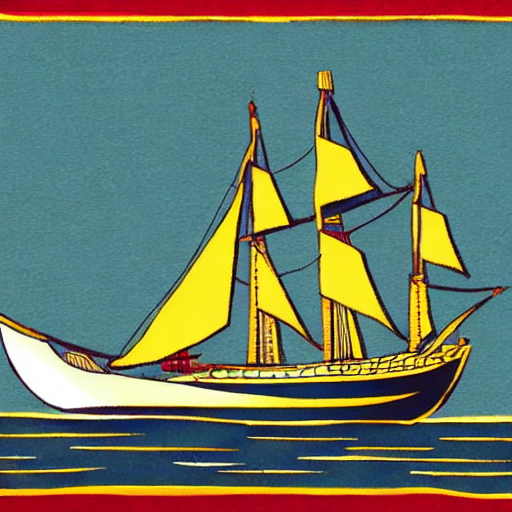

In [21]:
# Generamos una imagen con el modelo ORIGINAL (antes del finetuning).
# El prompt de comparacion esta definido en el panel de configuracion:
image_before = pipe(prompt).images[0]

# Guardamos la imagen para la comparacion final del entregable:
image_before.save(image_before_path)
image_before

# 2. Cargamos el dataset para finetunear

Cargamos el dataset [`gigant/oldbookillustrations`](https://huggingface.co/datasets/gigant/oldbookillustrations).

Este dataset tiene **varias columnas**, pero a nosotros solo nos interesan dos:
- **`1600px`**: contiene la imagen de la ilustración.
- **`info_alt`**: contiene la descripción (texto) de la imagen.

Como las imágenes **no son cuadradas** (la altura varía), aplicamos dos filtros:
1. Nos quedamos solo con las filas que tienen descripción (`info_alt` no nula).
2. Nos quedamos solo con las imágenes **casi cuadradas** (relación ancho/alto entre 0.8 y
   1.2). Así, al recortar a 512x512, el *crop* descarta muy poco de la ilustración. El
   dataset tiene 4k+ imágenes, por lo que aún quedan muestras de sobra para entrenar.

Además limitamos opcionalmente el número de muestras con `max_train_samples` (pon `None`
para usar todas las disponibles).

In [22]:
# Cargando el dataset de ilustraciones de libros antiguos.
# dataset_name, image_column, caption_column y max_train_samples estan en el panel de configuracion.
from io import BytesIO
from datasets import Image as HfImage

dataset = load_dataset(dataset_name, split="train")

# 1) Nos quedamos solo con las filas que tienen una descripcion valida (info_alt no nula).
#    Con input_columns el filtro mira SOLO la columna de texto, sin decodificar imagenes.
dataset = dataset.filter(
    lambda info_alt: info_alt is not None and len(str(info_alt).strip()) > 0,
    input_columns=[caption_column],
)

# 2) Como las imagenes NO son cuadradas (la altura varia), nos quedamos solo con las que son
#    "casi cuadradas". La tolerancia (square_ratio_tolerance) esta en el panel de configuracion:
#    con 0.1 aceptamos un ratio ancho/alto entre 0.9 y 1.1 (±10%). Asi el CenterCrop a 512x512
#    descarta muy poco de la ilustracion. Con 4k+ imagenes seguimos teniendo muestras de sobra.
#    Para no decodificar las imagenes enteras, desactivamos temporalmente la decodificacion y
#    leemos solo el tamaño de la cabecera (mucho mas rapido):
dataset = dataset.cast_column(image_column, HfImage(decode=False))

# Bornes del ratio ancho/alto derivados de la tolerancia configurada:
min_aspect_ratio = 1 - square_ratio_tolerance
max_aspect_ratio = 1 + square_ratio_tolerance

def is_near_square(img):
    try:
        with Image.open(BytesIO(img["bytes"])) as im:
            w, h = im.size
        return min_aspect_ratio <= (w / h) <= max_aspect_ratio
    except Exception:
        return False

dataset = dataset.filter(is_near_square, input_columns=[image_column])

# Reactivamos la decodificacion de la imagen para el resto del notebook (entrenamiento):
dataset = dataset.cast_column(image_column, HfImage(decode=True))

print(f"Muestras casi cuadradas con descripcion: {len(dataset)}")

if max_train_samples:
    dataset = dataset.select(range(min(max_train_samples, len(dataset))))

print(f"Numero de muestras de entrenamiento: {len(dataset)}")

# Comprobamos el tamaño de una imagen del dataset:
size = dataset[0][image_column].size
print(f"Tamaño de la primera imagen del dataset (ancho, alto): {size}")
print(f"Ejemplo de descripcion (info_alt): {dataset[0][caption_column]}")

Muestras casi cuadradas con descripcion: 335
Numero de muestras de entrenamiento: 200
Tamaño de la primera imagen del dataset (ancho, alto): (1600, 1500)
Ejemplo de descripcion (info_alt): A high-strung kitchen boy breaks a bit of annoying news to a more lackadaisical chef


In [23]:
# Definimos las transformaciones necesarias para el dataset.
# (resolution en el panel de configuracion; la resolucion del modelo la encontramos en su model card)

# IMPORTANTE: las imagenes de este dataset NO son cuadradas (la altura varia).
# Por eso, en lugar de un simple Resize((512, 512)) que deformaria la imagen,
# primero redimensionamos el lado mas corto a 512 manteniendo el aspect ratio (Resize)
# y luego recortamos un cuadrado central de 512x512 (CenterCrop). Asi combinamos
# resize + crop respetando las proporciones originales de la ilustracion.
image_transforms = transforms.Compose([
    transforms.Resize(resolution),                           # resize del lado corto a 512 (mantiene proporcion)
    transforms.CenterCrop(resolution),                       # crop cuadrado central 512x512
    transforms.ToTensor(),                                   # convertir a tensor
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # normalizacion
])

Imagen transformada (512x512):


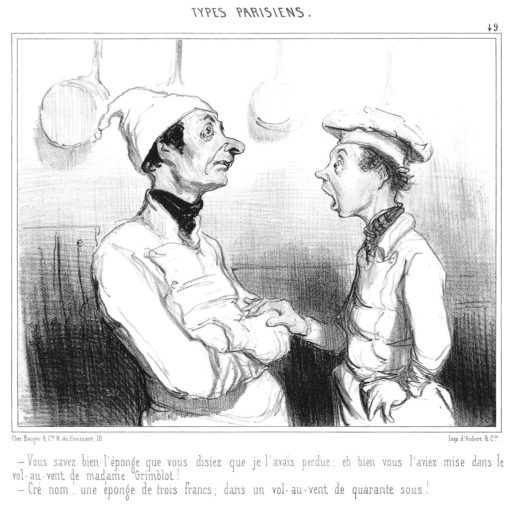

In [24]:
# Aplicamos la transformacion a una imagen del dataset para comprobar el resultado.
# Convertimos a RGB porque algunas ilustraciones pueden venir en otros modos (escala de grises, RGBA, ...):
original_image = dataset[0][image_column].convert("RGB")
transformed_image = image_transforms(original_image)

# Des-normalizamos solo para poder visualizarla:
transformed_pil_image = transforms.ToPILImage()(transformed_image * 0.5 + 0.5)

print("Imagen transformada (512x512):")
transformed_pil_image

In [25]:
# Creamos un Dataset wrapper para la hora del entrenamiento.
# Usamos las columnas configuradas (image_column / caption_column).
# batch_size esta definido en el panel de configuracion.

class Text2ImageDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        example = self.dataset[idx]
        image = image_transforms(example[image_column].convert("RGB"))
        token = tokenizer(
            str(example[caption_column]),
            padding="max_length",
            truncation=True,
            max_length=tokenizer.model_max_length,
            return_tensors="pt",
        )
        return {
            "pixel_values": image,
            "input_ids": token.input_ids.squeeze(0),
            "attention_mask": token.attention_mask.squeeze(0),
        }

train_dataset = Text2ImageDataset(dataset)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 3. Cargamos las componentes del modelo por separado

In [26]:
# Antes de cargar todas las componentes en GPU, liberamos el pipeline anterior y vaciamos la cache:
del pipe
torch.cuda.empty_cache()

In [27]:
# Tokenizador:
tokenizer = CLIPTokenizer.from_pretrained(pretrained_model_name, subfolder='tokenizer')

# Scheduler:
noise_scheduler = DDPMScheduler.from_pretrained(pretrained_model_name, subfolder="scheduler")

# Text Encoder (CLIP):
text_encoder = CLIPTextModel.from_pretrained(
    pretrained_model_name,
    subfolder="text_encoder",
).to(device)

# VAE: Autoencoder:
vae = AutoencoderKL.from_pretrained(
    pretrained_model_name,
    subfolder="vae",
).to(device)

# La UNet (es la unica componente que vamos a finetunear):
unet = UNet2DConditionModel.from_pretrained(
    pretrained_model_name,
    subfolder="unet",
).to(device)

/home/manu/dev/github.com/manupm87/pontia-generacion-imagenes/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 2156.00it/s]


In [28]:
# Congelamos los pesos del VAE y del Text Encoder, ya que solo queremos finetunear la UNet:
vae.eval()
text_encoder.eval()

for param in vae.parameters():
    param.requires_grad = False
for param in text_encoder.parameters():
    param.requires_grad = False

# 4. Preparamos el entrenamiento

In [29]:
# Optimizador (learning_rate en el panel de configuracion):
optimizer = torch.optim.AdamW(unet.parameters(), lr=learning_rate)

# Acelerador:
accelerator = Accelerator()
unet, optimizer, train_dataloader = accelerator.prepare(unet, optimizer, train_dataloader)
print(accelerator.device)

cuda


# 5. Proceso de entrenamiento: finetuning

In [30]:
# Training loop (num_epochs en el panel de configuracion):
unet.train()
for epoch in range(num_epochs):
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch}")

    for batch in progress_bar:

        # Se pasan los pixeles al espacio latente con el encoder del VAE:
        with torch.no_grad():
            latents = vae.encode(batch["pixel_values"].to(accelerator.device)).latent_dist.sample()
            latents = latents * 0.18215

        # Proceso de difusion hacia delante:
        # 1. Creamos ruido aleatorio
        noise = torch.randn_like(latents)
        # 2. Cogemos un timestep aleatorio:
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=latents.device).long()
        # 3. Añadimos ruido al vector del espacio latente:
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # Codificamos el texto:
        encoder_hidden_states = text_encoder(batch["input_ids"].to(accelerator.device))[0]

        # Con el vector con ruido, el timestep, y el vector de texto, hacemos la prediccion de ruido:
        noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

        # Calculamos el error y actualizamos los parametros:
        loss = torch.nn.functional.mse_loss(noise_pred, noise)
        accelerator.backward(loss)
        optimizer.step()
        optimizer.zero_grad()

        progress_bar.set_postfix(loss=loss.item())

Epoch 1: 100%|██████████| 34/34 [00:21<00:00,  1.57it/s, loss=0.136] 


In [31]:
# Guardamos el modelo finetuneado en local (output_dir en el panel de configuracion):
# unwrap_model por si accelerator ha envuelto la UNet:
unet_to_save = accelerator.unwrap_model(unet)
unet_to_save.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"Modelo finetuneado guardado en: {output_dir}")

Modelo finetuneado guardado en: ./finetuned-model-oldbooks


# 6. Subir el modelo finetuneado a Hugging Face

Una vez finetuneado el modelo, lo subimos a nuestro perfil de Hugging Face. Ya estamos
autenticados desde el inicio del notebook (login con `HF_API_KEY`), así que reutilizamos el
mismo token `hf_token`. Sustituye `tu-usuario` por tu nombre de usuario de Hugging Face.

In [32]:
# Repositorio destino en tu perfil de Hugging Face (repo_id en el panel de configuracion):
# Subimos la UNet finetuneada y el tokenizer al Hub.
# (push_to_hub crea el repositorio automaticamente si no existe)
unet_to_save.push_to_hub(repo_id, token=hf_token)
tokenizer.push_to_hub(repo_id, token=hf_token)

print(f"Modelo subido a: https://huggingface.co/{repo_id}")

Modelo subido a: https://huggingface.co/manupm87/finetuned-sd-1.4-oldbookillustrations


# 7. Cargamos el modelo ya finetuneado para generar imágenes

Cargamos la UNet finetuneada (desde la carpeta local, o desde nuestro repositorio de
Hugging Face) y la insertamos en el pipeline de Stable Diffusion, sustituyendo la UNet
original. Después generamos una imagen con el **mismo prompt** que usamos al principio.

In [33]:
# Opcion A: cargar la UNet finetuneada desde tu repositorio de Hugging Face:
# finetuned_unet = UNet2DConditionModel.from_pretrained(repo_id)

# Opcion B: cargar la UNet finetuneada desde la carpeta local:
finetuned_unet = UNet2DConditionModel.from_pretrained(output_dir)
finetuned_unet.to(device)

print('Modelo finetuneado cargado correctamente!')

Modelo finetuneado cargado correctamente!


In [34]:
from diffusers import StableDiffusionPipeline

# Cargamos el modelo pre-entrenado pero sustituyendo la UNet por la nuestra finetuneada:
pipe = StableDiffusionPipeline.from_pretrained(
    pretrained_model_name,
    unet=finetuned_unet,
).to(device)

Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 16.70it/s]


100%|██████████| 50/50 [00:02<00:00, 21.91it/s]


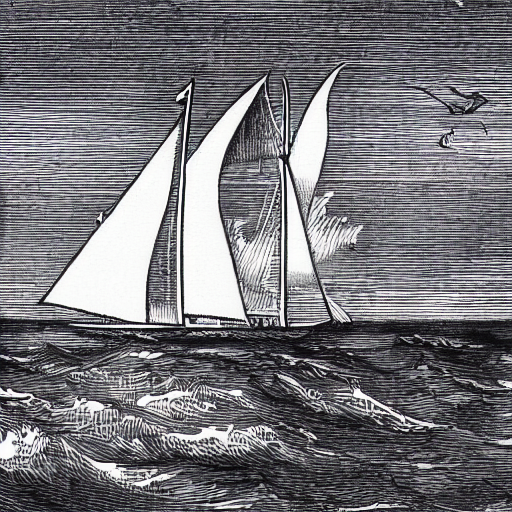

In [35]:
# Generamos una imagen con el modelo finetuneado usando el MISMO prompt de antes:
image_after = pipe(prompt).images[0]

# Guardamos la imagen para la comparacion final del entregable:
image_after.save(image_after_path)
image_after

# 8. Comparación: antes vs. después del finetuning

Mostramos lado a lado la imagen generada con el **mismo prompt** por el modelo original y
por el modelo finetuneado, para apreciar cómo el finetuning ha modificado el estilo hacia
el de las ilustraciones de libros antiguos.

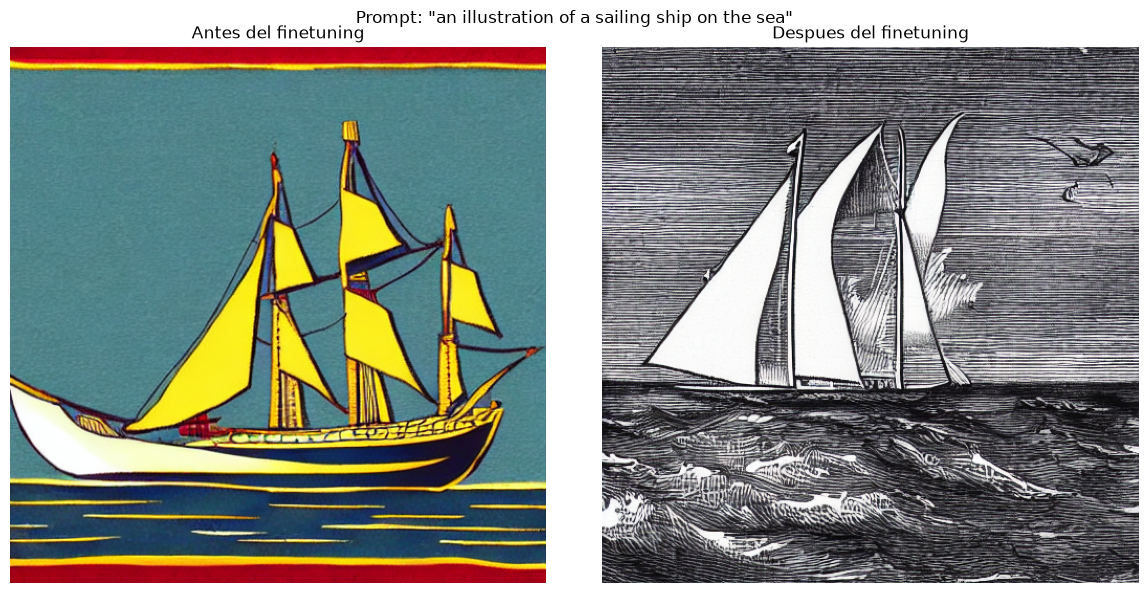

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_before)
axes[0].set_title("Antes del finetuning")
axes[0].axis("off")
axes[1].imshow(image_after)
axes[1].set_title("Despues del finetuning")
axes[1].axis("off")
fig.suptitle(f'Prompt: "{prompt}"')
plt.tight_layout()
plt.show()